#Exploratory data analysis and data preprocessing

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from src.load_data import load_data
from src.eda import basic_overview, product_distribution, narrative_availability, narrative_length_analysis

sns.set(style="whitegrid")


In [22]:
data_path = "../data/raw/complaints.csv"
chunksize = 50000

# Load first chunk just to inspect
chunk_iter = pd.read_csv(data_path, chunksize=chunksize, low_memory=False)
df_chunk = next(chunk_iter)
print("Chunk loaded:")
df_chunk.head()


Chunk loaded:


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [23]:
basic_overview(df_chunk)


Shape: (50000, 18)

Columns: 
 Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

Data Types: 
 Date received                    object
Product                          object
Sub-product                      object
Issue                            object
Sub-issue                        object
Consumer complaint narrative     object
Company public response          object
Company                          object
State                            object
ZIP code                         object
Tags                             object
Consumer consent provided?       object
Submitted via                    object
Date sent to company             object
Company res

Product
Credit reporting or other personal consumer reports        46253
Debt collection                                             2171
Credit card                                                  569
Checking or savings account                                  331
Money transfer, virtual currency, or money service           228
Mortgage                                                     122
Vehicle loan or lease                                        109
Student loan                                                 107
Payday loan, title loan, personal loan, or advance loan       68
Debt or credit management                                     24
Prepaid card                                                  18
Name: count, dtype: int64


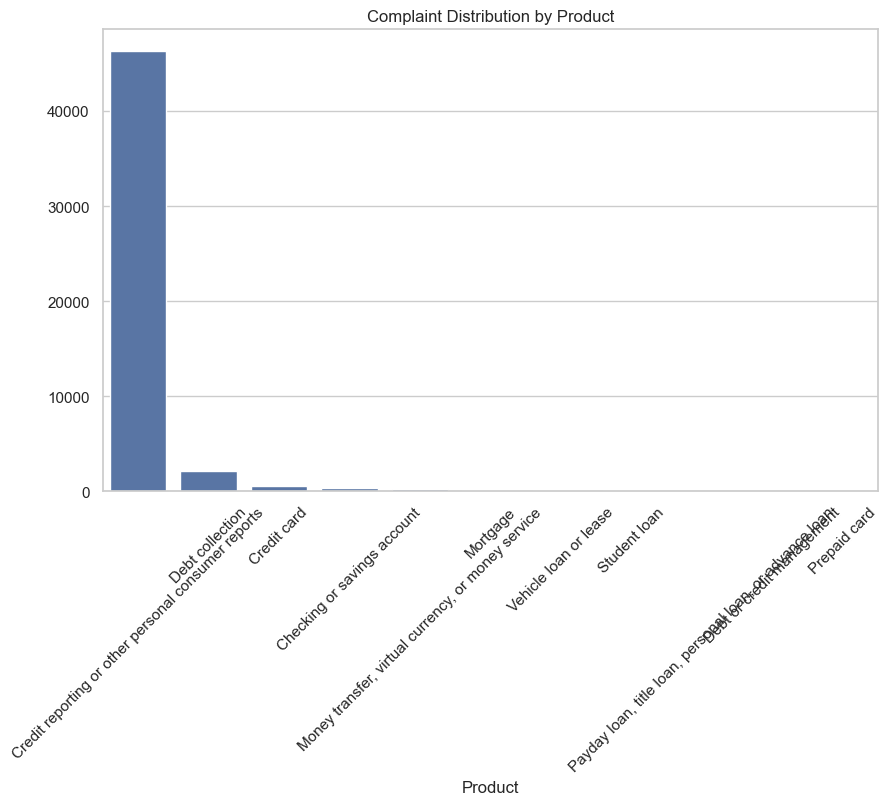

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [29]:
product_counts = df_chunk['Product'].value_counts()
print(product_counts)

# Seaborn plot
plt.figure(figsize=(10,6))
sns.barplot(x=product_counts.index, y=product_counts.values)
plt.xticks(rotation=45)
plt.title("Complaint Distribution by Product")
plt.show()

# Plotly interactive version (sample only if too large)
fig = px.bar(
    x=product_counts.index,
    y=product_counts.values,
    labels={'x':'Product', 'y':'Count'},
    title="Complaint Distribution by Product"
)
fig.show()


In [25]:
narrative_availability(df_chunk)


With narrative: 672
Without narrative: 49328


count     672.000000
mean      207.275298
std       171.918924
min         9.000000
25%        91.000000
50%       164.500000
75%       283.000000
max      1741.000000
Name: Consumer complaint narrative, dtype: float64


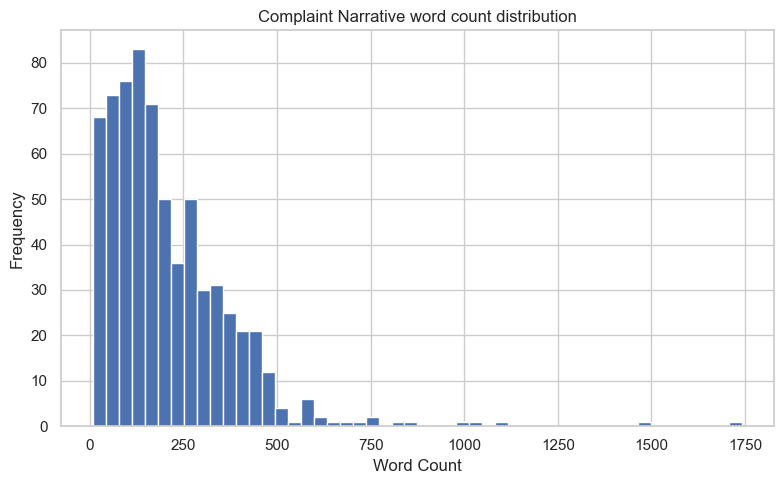

In [26]:
narrative_length_analysis(df_chunk)


In [27]:
# For longer plots or word analysis, sample 10,000 rows
sample_df = df_chunk.sample(n=min(10000, len(df_chunk)), random_state=42)
print(f"Using {len(sample_df)} rows for visualizations to save memory.")


Using 10000 rows for visualizations to save memory.
